<center>
    <h2>Evaluation protocole for the 2026 IA Pau Data Battle</h2>
</center>

---

This notebook provides you a protocol to evaluate your model for the data battle


### Why this notebook

This is not:

- The only and perfect way to evaluate your model.

The subject of evaluation is not trivial and there are different methods with their pro and con. The construction of the relevant method for evaluation is <span style="color:red">part of the subject of the data battle</span>. For instance, proposing a new relevant version of the risk estimation compatible with AI models would be very interesting.

- A mandatory step to participate to the Jury. You do not have to use this notebook to evaluate your models (but you may want). 

This is for :

- To provide a common evaluation framework. This enables the jury to better understand your results on the metric they understand and will see in other groups.

- Provide trust : we will send you blind test data which consists of subset of alerts. We will use the procedure described in this notebook to evaluate your results based on the prediction you will send to us. This enables us to validate your prediction.
 

### Two criteria : Risk and time gain 

As you know, our data from Meteorage consists of the location and date of lightning strikes from thunderstorms passing around areas to be protected (airports).

We assume :

- The last lightning of the alert $a$ is at time $t^a$ (all times and dates are in minutes)

- That a model produces $N^a$ predictions $p^a_i, i=1..N^a$ for the end of alert $a$. Each prediction $p^a_i$ is composed of a confidence score $s^a_i$, the date at which the prediction is emitted $d_i^a$ and the value of the prediction itself $\hat{t}_i^a$ which is the predicted time of the last lightning in the alert.

Now, we will estimate two criteria : Risk and time gain.

**A gain of time** $g_i^a$ for the prediction $p^a_i$ is measured as compared with the 30 minutes baseline :

$$g_i^a = t^a + 30 - \hat{t}_i^a$$

In practice, the overall Gain $G$ of a model will be the sum of gain over all alert contained in the dataset.


**Another important aspect is the risk** (_which measures how bad it is to be wrong_) of a lightning occurring on the airport after the end of the alert. There are multiple definitions for a relevant risk. We chose to consider the number of lightnings occurring within 3 km around the airport after the end of the alert. In practice, the risk associated to a model is computed on some training data.

$$R = \frac{M^{L3}}{N^{L3}}$$

Where the lightnings of the training data are denoted as $L = \{l_i, i=1..N^L\}$ and each lightning $l_i=(d_i,t_i)$. $N^{L3}$ is the number of lightning within a 3 kilometers distance and is computed as :

$$N^{L3} = \sum_i \mathbb{1}_{d_i<3}$$

$M^{L3} $ denotes the number of missed lightning (that is to say occurring after the end of the alarm) within a 3 kilometers distance. It is computed as

$$M^{L3} = \sum_i \mathbb{1}_{d_i<3\text{ } \& \text{ }\hat{t}_i^a < t_i \text{ }\& \text{ alert}(t_i) == a } $$

with alert$(t_i)$ returns the index of the alert for the lightning $t_i$.

Intuitively, a model $m$ that satisfies $R < 0.05$ ensures that less than 5% of lightning strikes will occur outside of alert periods. 

### How are combined the two criteria, ie, risk and time gain ($R$ and $G$)

The evaluator will set an acceptable risk value : $R_{accept}=0.02$.


To compute this risk, we must somehow select a prediction $p^a_i$ from the model. For this, we define a threshold $\theta$ and we select the predicted date $\hat{t^a}$ which verifies : 

$$\hat{t}^a = min_i\text{  }  \hat{t}_i^a, s^a_i > \theta $$

Given the selected prediction $\hat{t^a}$, we can compute a gain $g^a=t^a + 30 - \hat{t}^a$. 

To set the value of the threshold $\theta$, we test different values, and, among the values which provide a $R<R_{accept}$, we select the one with the highest gain $g^a$


### Provided python implementation

The rest of the notebook is organised as follows :

- Part 1 will generate fake predictions so that we can simulate an evaluation

- Part 2 will test different threshold $\theta$ and select the one with maximum gain $G$ while respecting the contraint on the risk $R$.

- Part 3 will evaluate the model given a supplied Theta. This last part will correspond to the code we will run with your submission.

In [18]:
import pandas as pd
## here replace with your own file
input_file = "dataset_set.csv"
df = pd.read_csv(input_file)

### Part 1 Generate fake predictions

We simply generate 20 predictions around the true date of the last lightning with a linear growth of the confidence threshold.

In [19]:

# get the end of alerts
last_light = df.groupby(['airport','airport_alert_id']).date.max()
last_light = pd.to_datetime(last_light, utc=True)

# generate some fake predictions around these ends of alerts
predictions= [(airport_name,alert_id,tms+pd.to_timedelta(i-20, unit="minutes"),tms+pd.to_timedelta(i, unit="minutes"), (i+20)/40) 
              for (airport_name, alert_id), tms in last_light.items()
             for i in range(-20,20,4)]

# convert to pandas
predictions = pd.DataFrame(predictions, columns=['airport','airport_alert_id','prediction_date','predicted_date_end_alert','confidence'])

In [20]:
predictions.head(6)

,airport,airport_alert_id,prediction_date,predicted_date_end_alert,confidence
0,Ajaccio,532.0,2023-01-17 06:37:34+00:00,2023-01-17 06:57:34+00:00,0.0
1,Ajaccio,532.0,2023-01-17 06:41:34+00:00,2023-01-17 07:01:34+00:00,0.1
2,Ajaccio,532.0,2023-01-17 06:45:34+00:00,2023-01-17 07:05:34+00:00,0.2
3,Ajaccio,532.0,2023-01-17 06:49:34+00:00,2023-01-17 07:09:34+00:00,0.3
4,Ajaccio,532.0,2023-01-17 06:53:34+00:00,2023-01-17 07:13:34+00:00,0.4
5,Ajaccio,532.0,2023-01-17 06:57:34+00:00,2023-01-17 07:17:34+00:00,0.5


In [21]:
predictions.to_csv('../predictions.csv')

### Part 2 Evaluate predictions

In [5]:
import pandas as pd
from tqdm import tqdm

In [14]:
# our 30 minutes baseline
MAX_GAP_MINUTES = 30


# here replace with your own file
input_file = "segment_alerts_all_airports_eval.csv"
df = pd.read_csv(input_file)


#building the Thetas
n_samples = 20
thetas = [i/n_samples for i in range(n_samples)]

# min distance at which we consider a lightning is really dangerous for the airport
min_dist = 3
# total number of dangerous lightning
tot_lightnings = len(df.loc[df.dist<min_dist])

# read prediction file and convert to timestampts
predictions = pd.read_csv('predictions.csv')
predictions.predicted_date_end_alert = pd.to_datetime(predictions.predicted_date_end_alert)

# group by alerts 
alerts = df.groupby(['airport','airport_alert_id'])

The following cell computes the number of missed dangerous lightning and the gain in time for the different thetas

In [15]:
results = {}
for theta in tqdm(thetas):
    pred_over_theta = predictions.loc[predictions['confidence'] >= theta ]
    pred_over_theta_min = pred_over_theta.groupby(['airport','airport_alert_id']).predicted_date_end_alert.min()
    gain, missed_lights = 0, 0
    for (airport, alert_id), end_alert_pred in pred_over_theta_min.items():
        lightings = alerts.get_group((airport, alert_id))
        end_alert_baseline = pd.to_datetime(lightings.date, utc=True).max() + pd.Timedelta(minutes=MAX_GAP_MINUTES)
        gain += (end_alert_baseline - end_alert_pred).total_seconds()
        missed_lights += sum(pd.to_datetime(lightings.loc[lightings.dist<min_dist].date, utc=True) > end_alert_pred )
    results[theta] = (gain, missed_lights)

100%|██████████| 20/20 [00:37<00:00,  1.87s/it]


Perform some visualisations : normally, the higher the Theta, the lower the gain and the lower the risk. This kind of visualisation can be usefull to show to the Jury the different compromises that your model can reach.

Text(0.5, 1.0, 'Gain of time and missed lightnings for different thresholds')

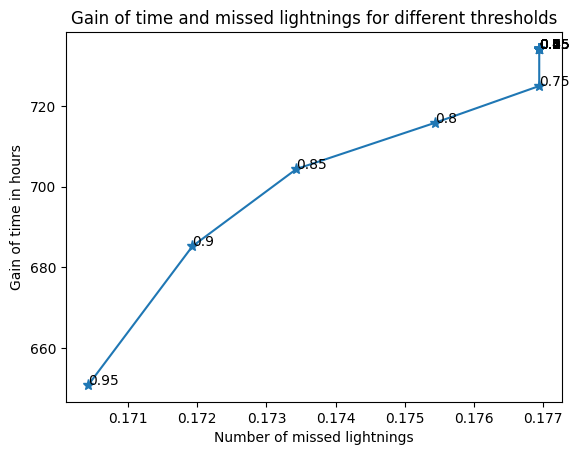

In [16]:
import matplotlib.pyplot as plt
gains = [results[theta][0]/3600 for theta in thetas]
missed = [results[theta][1] / tot_lightnings for theta in thetas]
plt.plot(missed, gains, marker='*', markersize=8)
for t,g,m in zip(thetas,gains,missed):
    plt.text(m, g, str(t))
plt.xlabel('Number of missed lightnings')
plt.ylabel('Gain of time in hours')
plt.title('Gain of time and missed lightnings for different thresholds')


**Selection of the best theta**

What is the theta with maximize the gain of time and respect the constraint on the acceptable risk ?

In [33]:
ACCEPTABLE_RISK = 0.02 # 0.02

(gain_of_time, theta, missing_lightnings) = max([ (gain_of_time, theta, missing_rate)  
     for (theta,(gain_of_time, missing_rate)) 
     in results.items() if missing_rate/tot_lightnings < ACCEPTABLE_RISK ])

ValueError: max() iterable argument is empty

In [20]:
print('The system enables to save',
      int(gain_of_time/3600),
      'hours, with a risk of',ACCEPTABLE_RISK,
      'by using a threshold on the confidence score with a value of',
      theta)

The system enables to save 639 hours, with a risk of 0.2 by using a threshold on the confidence score with a value of 0.7


### Part 3 Evaluate given a Theta

It is essentially the same code as before, its just that we evaluate it with one value of Theta. So you don't really need this code yourself. But this is what we will do with the predictions.csv file you might send us.


In [31]:
# redefining some variables
import pandas as pd
predictions = pd.read_csv('predictions.csv')
predictions.predicted_date_end_alert = pd.to_datetime(predictions.predicted_date_end_alert)
MAX_GAP_MINUTES = 30
input_file = "segment_alerts_all_airports_eval.csv"
df = pd.read_csv(input_file)
min_dist = 3 # at which distance a strike is considered dangerous
tot_lightnings = len(df.loc[df.dist<min_dist])
alerts = df.groupby(['airport','airport_alert_id'])

theta = 0.97 # using the theta value we obtained from the previous section

In [32]:
# Essentially the same code as in part 2 of this notebook

pred_over_theta = predictions.loc[predictions['confidence'] >= theta ]
pred_over_theta_min = pred_over_theta.groupby(['airport','airport_alert_id']).predicted_date_end_alert.min()
gain, missed_lights = 0, 0
for (airport, alert_id), end_alert_pred in pred_over_theta_min.items():
    lightings = alerts.get_group((airport, alert_id))
    end_alert_baseline = pd.to_datetime(lightings.date, utc=True).max() + pd.Timedelta(minutes=MAX_GAP_MINUTES)
    gain += (end_alert_baseline - end_alert_pred).total_seconds()
    missed_lights += sum(pd.to_datetime(lightings.loc[lightings.dist<min_dist].date, utc=True) > end_alert_pred )

print('for a theta of',theta,
      'the gain of time is',int(gain/3600),
      'hours, with a rate of missing lightnings',missed_lights/tot_lightnings)

for a theta of 0.97 the gain of time is 569 hours, with a rate of missing lightnings 0.15639097744360902


### Conclusion

Feel free to play and modify this notebook in any way you like or judge relevant. 

The distance of 3km was suggested by Sébastien from Meteorage, but it might be interesting to provide results for other values as well.

One thing we wondered but did not consider in the notebook is to compute a gain, not only from the 30 minutes baseline, but also by taking into account the moment of the prediction. Intuitively, for the same prediction, it is better to send the information as soon as possible. With our definition, the Gain is measured only between the baseline and the value of the prediction, and the date is not taken into account. If you worked on this aspect, that's perfectly legitimate!

